# Multi-equilibrium density vs. pedestal pressure ratio

For each successfully converged run in `multiequil_kbmavg` (`success.npy`), extract the final electron density at the pedestal boundaries (`psiN = 0.85` and `psiN = 1`) and plot against `p_pedestal_predicted / p_ped_h` (`ped_h / (p_ped_h / 1e6)`), where the denominator is the pfile pedestal-top pressure `n_e T_e + n_i T_i` at `ψ_N = 1 - Δ`. Color by pfile axis pressure `p(ψ_N=0)`.


In [1]:
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
from pathlib import Path

In [2]:
# Inputs
out_dir = Path('multiequil_kbmavg')
psiN_inner = 0.85
psiN_outer = 1.0

In [3]:
success = np.load(out_dir / 'success.npy', allow_pickle=True)
print(f'{len(success)} successful equilibria')

97 successful equilibria


In [4]:
def read_pfile(path):
    data = {}
    key = ''
    with open(path) as f:
        for line in f:
            if '3 N Z A' in line:
                break
            if line.startswith('201'):
                key = line.split()[2]
                data[key] = np.array([])
                data[f'{key}_psi'] = np.array([])
            else:
                psi, dat, _ = line.split()
                psi = float(psi)
                dat = float(dat)
                data[key] = np.append(data[key], dat)
                data[f'{key}_psi'] = np.append(data[f'{key}_psi'], psi)
    return data

In [ ]:
def last_ne_iter(eq_dir: Path):
    """Return path to the highest-index ne_iter_*.npy in eq_dir."""
    iters = list(eq_dir.glob('ne_iter_*.npy'))
    if not iters:
        return None
    return max(iters, key=lambda p: int(p.stem.split('_')[-1]))


def ne_at_psiN(sol, psiN, psiN_inner=0.85, psiN_outer=1.0):
    """
    Map converged ne(x) onto psiN.

    The density solver domain runs from psiN_inner (x = x[0]) to
    psiN_outer / separatrix (x = 0 = x[-1]). Interpolate linearly in x
    after mapping the requested psiN onto that radial coordinate.
    """
    x = np.asarray(sol['x'], dtype=float)
    ne = np.asarray(sol['y'], dtype=float)
    # Linear map psiN -> x using the known endpoints of the solve domain
    x_at_psi = np.interp(psiN, [psiN_inner, psiN_outer], [x[0], x[-1]])
    return float(np.interp(x_at_psi, x, ne))


ne_inner = []
ne_outer = []
p_ratio = []
tags = []
p_ped_h_arr = []
p_psiN0 = []

for out_dict in success:
    equil_tag = Path(out_dict['mhd_fp']).name[1:]  # g152960.03500 -> 152960.03500
    eq_dir = out_dir / equil_tag
    npy_path = last_ne_iter(eq_dir)
    if npy_path is None:
        print(f'skipping {equil_tag}: no ne_iter files')
        continue

    sol = np.load(npy_path, allow_pickle=True).item()

    # Calculate pressure using pfile
    # Extract profiles
    pf = read_pfile(out_dict['kprof_fp'])

    # Store pfile information
    T_e_pfile = pf['te(KeV)'] # T_e values (keV) evaluated at psi_Te_eval
    psi_Te_eval_pfile = pf['te(KeV)_psi'] # psi_N values at which T_e is evaluated

    n_e_pfile = pf['ne(10^20/m^3)'] * 1e20 # n_e values (10^20/m^3 -> m^-3) evaluated at psi_ne_eval
    psi_ne_eval = pf['ne(10^20/m^3)_psi'] # psi_N values at which n_e is evaluated

    # T_i_pfile = T_e_pfile # T_e values (keV) evaluated at psi_Te_eval
    # psi_Ti_eval_pfile = psi_Te_eval_pfile # psi_N values at which T_e is evaluated

    # n_i_pfile = n_e_pfile # n_e values (10^20/m^3 -> m^-3) evaluated at psi_ne_eval
    # psi_ni_eval = psi_ne_eval # psi_N values at which n_e is evaluated

    T_i_pfile = pf['ti(KeV)'] # T_e values (keV) evaluated at psi_Te_eval
    psi_Ti_eval_pfile = pf['ti(KeV)_psi'] # psi_N values at which T_e is evaluated

    n_i_pfile = pf['ni(10^20/m^3)'] * 1e20 # n_e values (10^20/m^3 -> m^-3) evaluated at psi_ne_eval
    psi_ni_eval = pf['ni(10^20/m^3)_psi'] # psi_N values at which n_e is evaluated

    # "Correct" pressure: pfile total pressure at ped [Pa]
    T_e_ped = np.interp(1-out_dict['ped_wid'], psi_Te_eval_pfile, T_e_pfile) * 1e3  # keV -> eV
    n_e_ped = np.interp(1-out_dict['ped_wid'], psi_ne_eval, n_e_pfile)
    T_i_ped = np.interp(1-out_dict['ped_wid'], psi_Ti_eval_pfile, T_i_pfile) * 1e3  # keV -> eV
    n_i_ped = np.interp(1-out_dict['ped_wid'], psi_ni_eval, n_i_pfile)
    p_ped_h = (n_e_ped * T_e_ped + n_i_ped * T_i_ped) * 1.602176634e-19

    T_e_ped_psiN0 = np.interp(0, psi_Te_eval_pfile, T_e_pfile) * 1e3  # keV -> eV
    n_e_ped_psiN0 = np.interp(0, psi_ne_eval, n_e_pfile)
    T_i_ped_psiN0 = np.interp(0, psi_Ti_eval_pfile, T_i_pfile) * 1e3  # keV -> eV
    n_i_ped_psiN0 = np.interp(0, psi_ni_eval, n_i_pfile)
    p_ped_psiN0 = (n_e_ped_psiN0 * T_e_ped_psiN0 + n_i_ped_psiN0 * T_i_ped_psiN0) * 1.602176634e-19

    # ped_h [MPa], p_ped_h [Pa] from pfile at pedestal top
    ratio = out_dict['ped_h'] / (p_ped_h / 1e6)

    ne_inner.append(ne_at_psiN(sol, psiN_inner, psiN_inner, psiN_outer))
    ne_outer.append(ne_at_psiN(sol, psiN_outer, psiN_inner, psiN_outer))
    p_ratio.append(ratio)
    tags.append(equil_tag)
    p_ped_h_arr.append(p_ped_h)
    p_psiN0.append(p_ped_psiN0)



ne_inner = np.asarray(ne_inner)
ne_outer = np.asarray(ne_outer)
p_ratio = np.asarray(p_ratio)
print(f'extracted densities for {len(p_ratio)} equilibria')


extracted densities for 97 equilibria


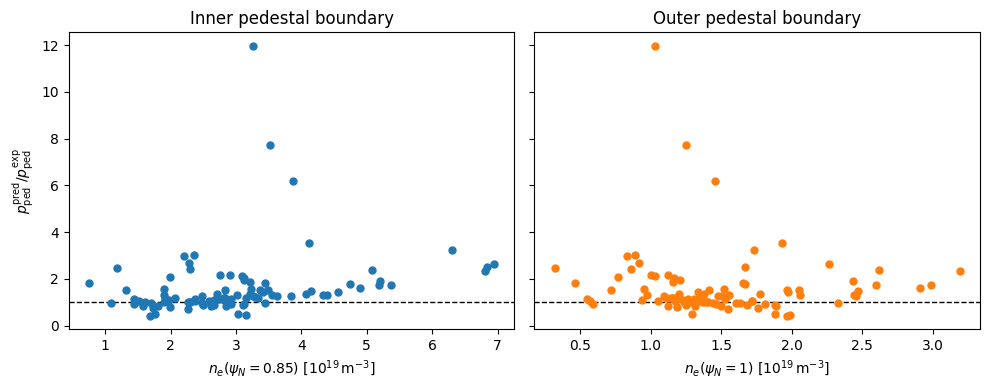

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

axes[0].plot(ne_inner / 1e19, p_ratio, 'o', color='tab:blue', ms=5)
axes[0].set_xlabel(r'$n_e(\psi_N = 0.85)$ [$10^{19}\,\mathrm{m}^{-3}$]')
axes[0].set_ylabel(r'$p_{\mathrm{ped}}^{\mathrm{pred}} / p_{\mathrm{ped}}^{\mathrm{exp}}$')
axes[0].set_title('Inner pedestal boundary')
axes[0].axhline(1.0, color='k', ls='--', lw=1, zorder=0)

axes[1].plot(ne_outer / 1e19, p_ratio, 'o', color='tab:orange', ms=5)
axes[1].set_xlabel(r'$n_e(\psi_N = 1)$ [$10^{19}\,\mathrm{m}^{-3}$]')
axes[1].set_title('Outer pedestal boundary')
axes[1].axhline(1.0, color='k', ls='--', lw=1, zorder=0)

fig.tight_layout()
plt.show()


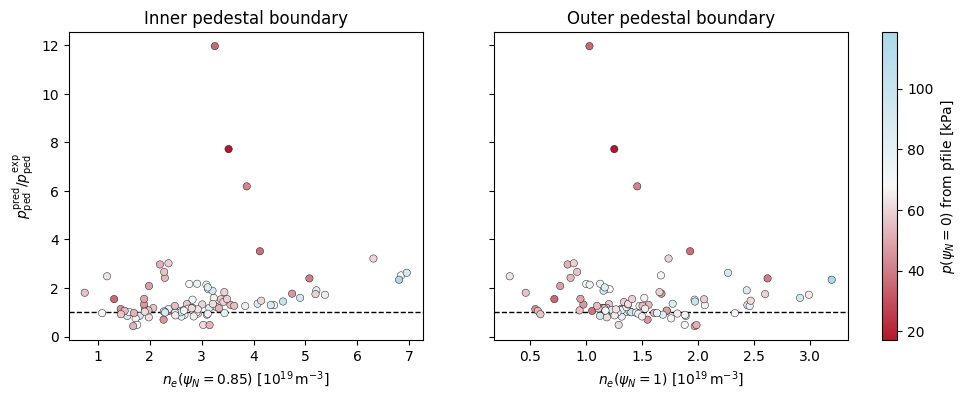

In [19]:
# Same plots, colored by pfile p(psiN=0)
geqdsk_dir = Path('/mnt/homes_global/jal2351/software/sc_inputs/CAKEgeqdsks')


def p_at_psiN0(mhd_fp):
    """Return GEQDSK pressure [Pa] at psiN=0 (magnetic axis), or nearest grid point."""
    with open(mhd_fp, 'r') as fid:
        line = fid.readline()
        nr = int(line[48:].split()[-2])
        # Skip 4 header lines (rdim/zdim/... through second skip block)
        for _ in range(4):
            fid.readline()

        def read_1d(n):
            vals = np.zeros(n)
            j = 0
            line = ''
            for i in range(n):
                if j == 0:
                    line = fid.readline()
                vals[i] = float(line[j:j + 16])
                j += 16
                if j == 16 * 5:
                    j = 0
            return vals

        _fpol = read_1d(nr)
        pres = read_1d(nr)

    psi_N = np.linspace(0.0, 1.0, nr)
    # Exact axis value is psi_N[0]; interp still picks the nearest grid point if needed
    return float(np.interp(0.0, psi_N, pres))

p_axis = []
for i, tag in enumerate(tags):
    mhd_fp = geqdsk_dir / f'g{tag}'
    if not mhd_fp.exists():
        # Fall back to path stored in success.npy
        match = next(s for s in success if Path(s['mhd_fp']).name[1:] == tag)
        mhd_fp = Path(match['mhd_fp'])
    # p_axis.append(p_at_psiN0(mhd_fp))
    p_axis.append(p_psiN0[i])
p_axis = np.asarray(p_axis)

from matplotlib.colors import LinearSegmentedColormap
# Red (low p) -> white -> light blue (high p); stop before RdBu's dark-blue end
cmap_red_lightblue = LinearSegmentedColormap.from_list(
    'red_lightblue',
    ['#b2182b', '#f7f7f7', '#abd9e9'],
)

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)

sc0 = axes[0].scatter(
    ne_inner / 1e19, p_ratio, c=p_axis / 1e3, cmap=cmap_red_lightblue, s=28, edgecolors='k', linewidths=0.3,
)
axes[0].set_xlabel(r'$n_e(\psi_N = 0.85)$ [$10^{19}\,\mathrm{m}^{-3}$]')
axes[0].set_ylabel(r'$p_{\mathrm{ped}}^{\mathrm{pred}} / p_{\mathrm{ped}}^{\mathrm{exp}}$')
axes[0].set_title('Inner pedestal boundary')
axes[0].axhline(1.0, color='k', ls='--', lw=1, zorder=0)

sc1 = axes[1].scatter(
    ne_outer / 1e19, p_ratio, c=p_axis / 1e3, cmap=cmap_red_lightblue, s=28, edgecolors='k', linewidths=0.3,
)
axes[1].set_xlabel(r'$n_e(\psi_N = 1)$ [$10^{19}\,\mathrm{m}^{-3}$]')
axes[1].set_title('Outer pedestal boundary')
axes[1].axhline(1.0, color='k', ls='--', lw=1, zorder=0)

cbar = fig.colorbar(sc1, ax=axes, fraction=0.046, pad=0.04)
cbar.set_label(r'$p(\psi_N=0)$ from pfile [kPa]')

# fig.tight_layout()
plt.show()


In [20]:
# Shots with p_pred / p_ped > 4
mask = p_ratio > 4
high_ratio = sorted(
    zip(np.asarray(tags)[mask], p_ratio[mask]),
    key=lambda t: t[1],
    reverse=True,
)
print(f'{len(high_ratio)} equilibria with p_pred/p_ped > 4:\n')
for tag, ratio in high_ratio:
    shot = tag.split('.')[0]
    print(f'  shot {shot}  ({tag})  p_pred/p_ped = {ratio:.3f}')


3 equilibria with p_pred/p_ped > 4:

  shot 154929  (154929.02200)  p_pred/p_ped = 11.972
  shot 154959  (154959.02500)  p_pred/p_ped = 7.728
  shot 154521  (154521.02800)  p_pred/p_ped = 6.191


In [21]:
# Shots with p_pred / p_ped < 1.2 and > 1
mask = (p_ratio > 1) & (p_ratio < 1.2)
high_ratio = sorted(
    zip(np.asarray(tags)[mask], p_ratio[mask]),
    key=lambda t: t[1],
    reverse=True,
)
print(f'{len(high_ratio)} equilibria with p_pred/p_ped > 1 and < 1.2:\n')
for tag, ratio in high_ratio:
    shot = tag.split('.')[0]
    print(f'  shot {shot}  ({tag})  ratio = {ratio:.3f}')


23 equilibria with p_pred/p_ped > 1 and < 1.2:

  shot 154863  (154863.05500)  ratio = 1.185
  shot 153828  (153828.02500)  ratio = 1.178
  shot 154853  (154853.04015)  ratio = 1.172
  shot 158077  (158077.02950)  ratio = 1.169
  shot 158083  (158083.02850)  ratio = 1.163
  shot 158081  (158081.04900)  ratio = 1.162
  shot 158036  (158036.03085)  ratio = 1.147
  shot 154849  (154849.02075)  ratio = 1.138
  shot 157109  (157109.01963)  ratio = 1.130
  shot 152960  (152960.03500)  ratio = 1.126
  shot 158080  (158080.02850)  ratio = 1.121
  shot 157381  (157381.03200)  ratio = 1.097
  shot 157375  (157375.02000)  ratio = 1.095
  shot 157263  (157263.02400)  ratio = 1.077
  shot 154372  (154372.04000)  ratio = 1.070
  shot 158084  (158084.02850)  ratio = 1.068
  shot 157188  (157188.02060)  ratio = 1.060
  shot 153778  (153778.02170)  ratio = 1.056
  shot 153489  (153489.01800)  ratio = 1.052
  shot 157372  (157372.02000)  ratio = 1.031
  shot 157371  (157371.02000)  ratio = 1.024
  shot 

kbmavg successes: 97
EPEDNN successes: 100
common equilibria: 97
filtered 3 EPEDNN-only tags (kbmavg failed): ['150840.03000', '153032.04475', '153100.03000']


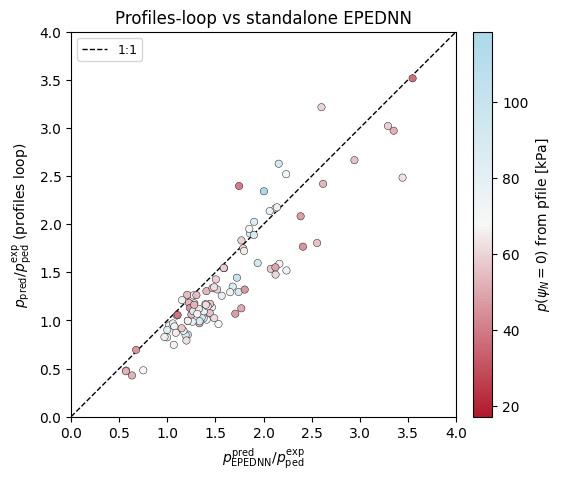

In [22]:
# Compare profiles-loop p_pred/p_ped (multiequil_kbmavg)
# vs standalone EPEDNN p_EPEDNN_pred/p_ped (multiequil_epednn_pfile)
# Denominator is pfile pedestal-top pressure p_ped_h; color by pfile p(ψN=0).
kbm_dir = Path('multiequil_kbmavg')
eped_dir = Path('multiequil_epednn_pfile')

success_kbm = np.load(kbm_dir / 'success.npy', allow_pickle=True)
success_eped = np.load(eped_dir / 'success.npy', allow_pickle=True)

def tag_of(out_dict):
    return Path(out_dict['mhd_fp']).name[1:]  # g152960.03500 -> 152960.03500

# Align arrays (ordered like tags) onto tag keys
p_ped_h_by_tag = dict(zip(tags, p_ped_h_arr))
p_psiN0_by_tag = dict(zip(tags, p_psiN0))

def p_ratio_of(out_dict, tag):
    # ped_h [MPa], p_ped_h [Pa] from pfile at pedestal top
    return float(out_dict['ped_h'] / (p_ped_h_by_tag[tag] / 1e6))

kbm_by_tag = {tag_of(d): d for d in success_kbm}
eped_by_tag = {tag_of(d): d for d in success_eped}
# Keep only equilibria successful in both runs *and* with pfile pressures
common_tags = sorted(set(kbm_by_tag) & set(eped_by_tag) & set(p_ped_h_by_tag))
only_eped = sorted(set(eped_by_tag) - set(kbm_by_tag))
print(f'kbmavg successes: {len(success_kbm)}')
print(f'EPEDNN successes: {len(success_eped)}')
print(f'common equilibria: {len(common_tags)}')
if only_eped:
    print(f'filtered {len(only_eped)} EPEDNN-only tags (kbmavg failed): {only_eped}')

p_ratio_kbm = np.array([p_ratio_of(kbm_by_tag[t], t) for t in common_tags])
p_ratio_eped = np.array([p_ratio_of(eped_by_tag[t], t) for t in common_tags])
if len(common_tags) == 0:
    raise RuntimeError('No common successful equilibria between kbmavg and EPEDNN outputs.')

p_axis = np.array([p_psiN0_by_tag[t] for t in common_tags])

from matplotlib.colors import LinearSegmentedColormap
cmap_red_lightblue = LinearSegmentedColormap.from_list(
    'red_lightblue',
    ['#b2182b', '#f7f7f7', '#abd9e9'],
)

fig, ax = plt.subplots(figsize=(5.5, 5))
sc = ax.scatter(
    p_ratio_eped, p_ratio_kbm,
    c=p_axis / 1e3, cmap=cmap_red_lightblue, s=28, edgecolors='k', linewidths=0.3,
)
lims = [
    0.0,
    max(1.05, float(np.nanmax([p_ratio_eped.max(), p_ratio_kbm.max()])) * 1.05),
]
ax.plot(lims, lims, 'k--', lw=1, zorder=0, label='1:1')
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_aspect('equal', adjustable='box')
ax.set_xlabel(r'$p_{\mathrm{EPEDNN}}^{\mathrm{pred}} / p_{\mathrm{ped}}^{\mathrm{exp}}$')
ax.set_ylabel(r'$p_{\mathrm{pred}} / p_{\mathrm{ped}}^{\mathrm{exp}}$ (profiles loop)')
ax.set_title('Profiles-loop vs standalone EPEDNN')
ax.legend(loc='upper left', fontsize=9)

cbar = fig.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label(r'$p(\psi_N=0)$ from pfile [kPa]')
ax.set_xlim([0, 4])
ax.set_ylim([0, 4])

plt.show()
